In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split , RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings
import joblib
import json   
warnings.filterwarnings('ignore')

In [31]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
store = pd.read_csv('store.csv')

In [32]:
print("Train shape:", train.shape)
print("Test  shape:", test.shape)
print("Store shape:", store.shape)

Train shape: (1017209, 9)
Test  shape: (41088, 8)
Store shape: (1115, 10)


In [33]:
train_merged = train.merge(store, on='Store', how='left')
test_merged  = test.merge(store,  on='Store', how='left')

print("After merge -> train:", train_merged.shape, "| test:", test_merged.shape)

After merge -> train: (1017209, 18) | test: (41088, 17)


In [34]:
train_merged = train_merged[train_merged['Open'] != 0].copy()
test_merged['Open'] = test_merged['Open'].fillna(1)

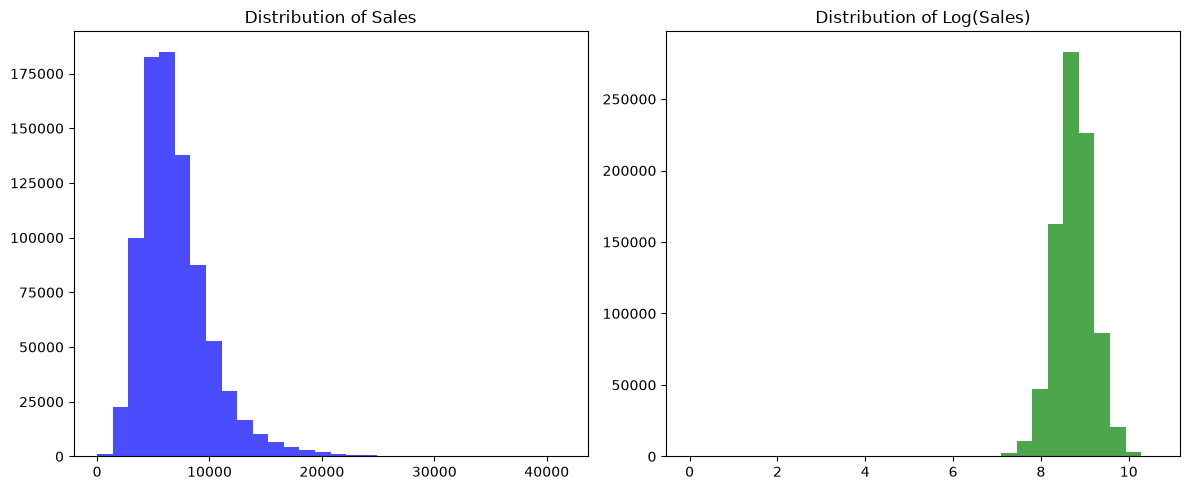

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(train_merged['Sales'], bins=30, color='blue', alpha=0.7)
ax[0].set_title('Distribution of Sales')
ax[1].hist(np.log1p(train_merged['Sales']), bins=30, color='green', alpha=0.7)
ax[1].set_title('Distribution of Log(Sales)')
plt.tight_layout()
plt.show()


In [36]:
train_merged['sales_log'] = np.log1p(train_merged['Sales'])


In [37]:
for df in [train_merged, test_merged]:
    df['Date'] = pd.to_datetime(df['Date'])
    df['year']        = df['Date'].dt.year
    df['month']       = df['Date'].dt.month
    df['day']         = df['Date'].dt.day
    df['weekofyear']  = df['Date'].dt.isocalendar().week.astype(int)
    df['IsWeekend']   = (df['DayOfWeek'] >= 6).astype(int)

In [38]:
def is_promo_month(row):
    if pd.isna(row['PromoInterval']):
        return 0
    months = row['PromoInterval'].split(',')
    month_abbr = row['Date'].strftime('%b')
    return int(month_abbr in months)

In [39]:
train_merged['IsPromoMonth'] = train_merged.apply(is_promo_month, axis=1)
test_merged['IsPromoMonth']  = test_merged.apply(is_promo_month, axis=1)


In [40]:
def competition_months(row):
    if pd.isna(row['CompetitionOpenSinceYear']) or pd.isna(row['CompetitionOpenSinceMonth']):
        return -1
    comp_date = pd.Timestamp(
        year=int(row['CompetitionOpenSinceYear']),
        month=int(row['CompetitionOpenSinceMonth']),
        day=1
    )
    return (row['Date'].year - comp_date.year) * 12 + (row['Date'].month - comp_date.month)

train_merged['CompetitionMonths'] = train_merged.apply(competition_months, axis=1)
test_merged['CompetitionMonths']  = test_merged.apply(competition_months, axis=1)

In [41]:
train_merged['StateHoliday'] = train_merged['StateHoliday'].astype(str)
test_merged['StateHoliday']  = test_merged['StateHoliday'].astype(str)

In [ ]:
categorical_features = ['StoreType', 'Assortment', 'StateHoliday', 'PromoInterval']
train_merged['_set'] = 'train'
test_merged['_set']  = 'test'
combined = pd.concat([train_merged, test_merged], axis=0, ignore_index=True)
combined = pd.get_dummies(combined, columns=categorical_features, drop_first=True)
train_merged = combined[combined['_set'] == 'train'].drop(columns='_set').copy()
test_merged  = combined[combined['_set'] == 'test'].drop(columns='_set').copy()

print("After encoding -> train:", train_merged.shape, "| test:", test_merged.shape)



After encoding -> train: (844392, 33) | test: (41088, 33)


In [18]:
drop_cols = ['Sales', 'Customers', 'Date', 'sales_log']
feature_cols = [c for c in train_merged.columns if c not in drop_cols + ['Id']]

X = train_merged[feature_cols].copy()
y = train_merged['sales_log'].copy()
X_test_final = test_merged[feature_cols].copy()

print("Number of features:", len(feature_cols))


Number of features: 28


In [19]:
train_merged_sorted = train_merged.sort_values('Date')
split_idx = int(len(train_merged_sorted) * 0.8)

train_part = train_merged_sorted.iloc[:split_idx]
val_part   = train_merged_sorted.iloc[split_idx:]

X_train = train_part[feature_cols]
y_train = train_part['sales_log']
X_val   = val_part[feature_cols]
y_val   = val_part['sales_log']

In [20]:
X_train = X_train.fillna(-1)
X_val   = X_val.fillna(-1)
X_test_final = X_test_final.fillna(-1)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_log = lr.predict(X_val)

rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_log))
r2_log   = r2_score(y_val, y_pred_log)

print("\n=== Linear Regression ===")
print(f"RMSE (log space): {rmse_log:.4f}")
print(f"R²   (log space): {r2_log:.4f}")

y_pred_price = np.expm1(y_pred_log)
y_val_price  = np.expm1(y_val)
rmse_price   = np.sqrt(mean_squared_error(y_val_price, y_pred_price))
print(f"RMSE (price space): {rmse_price:.2f}")


=== Linear Regression ===
RMSE (log space): 0.3596
R²   (log space): 0.2448
RMSE (price space): 2740.49


In [ ]:
param_dist = {
    'n_estimators':      [100, 200, 300],       
    'max_depth':         [10, 15, 20, 25, 30],
    'min_samples_split': [2, 5],                 
    'min_samples_leaf':  [1, 2],                  
    'max_features':      ['sqrt', 'log2'],     
}
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=2
)
random_search.fit(X_train, y_train)
print("\n=== Best Params ===")
print(random_search.best_params_)
print(f"\nBest CV RMSE: {-random_search.best_score_:.4f}")
best_rf = random_search.best_estimator_
joblib.dump(best_rf, 'best_rf_model.pkl')

y_pred_rf_log = best_rf.predict(X_val)

rmse_rf_log = np.sqrt(mean_squared_error(y_val, y_pred_rf_log))
r2_rf_log   = r2_score(y_val, y_pred_rf_log)

print("\n=== Best Random Forest ===")
print(f"RMSE (log): {rmse_rf_log:.4f}")
print(f"R²   (log): {r2_rf_log:.4f}")

y_pred_rf_price = np.expm1(y_pred_rf_log)
rmse_rf_price   = np.sqrt(mean_squared_error(y_val_price, y_pred_rf_price))
print(f"RMSE (price): {rmse_rf_price:.2f}")
with open('best_params.json', 'w') as f:
    json.dump(random_search.best_params_, f, indent=2)
print("✅  Best params saved as 'best_params.json'")

Fitting 3 folds for each of 5 candidates, totalling 15 fits

=== Best Params ===
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}

Best CV RMSE: -0.7432

=== Best Random Forest ===
RMSE (log): 0.1990
R²   (log): 0.7687
RMSE (price): 1612.69
✅ Best params saved as 'best_params.json'


In [ ]:
xparam_dist = {
    'n_estimators':     [300, 500, 800],
    'max_depth':        [4, 6, 8, 10],
    'learning_rate':    [0.01, 0.03, 0.05, ],
    'subsample':        [0.6, 0.7, 0.8, 0.9, ],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.3],
    'reg_alpha':        [0, 0.1],
    'reg_lambda':       [1, 1.5],
}


xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    tree_method='hist'   
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,                     
    cv=2,                        
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=2
)

random_search.fit(X_train, y_train)

print("\n=== Best Params ===")
print(random_search.best_params_)

print(f"\n=== Best CV RMSE (log) === {(-random_search.best_score_):.4f}")

best_xgb = random_search.best_estimator_

y_pred_xgb_log = best_xgb.predict(X_val)

rmse_xgb_log = np.sqrt(mean_squared_error(y_val, y_pred_xgb_log))
r2_xgb_log   = r2_score(y_val, y_pred_xgb_log)

print("\n=== Best XGBoost ===")
print(f"RMSE (log): {rmse_xgb_log:.4f}")
print(f"R²   (log): {r2_xgb_log:.4f}")

y_pred_xgb_price = np.expm1(y_pred_xgb_log)
rmse_xgb_price   = np.sqrt(mean_squared_error(y_val_price, y_pred_xgb_price))
print(f"RMSE (price): {rmse_xgb_price:.2f}")


joblib.dump(best_xgb, 'best_xgb_model.pkl')
print("\n Model saved as 'best_xgb_model.pkl'")

with open('best_xgb_params.json', 'w') as f:
    json.dump(random_search.best_params_, f, indent=2)
print("Params saved as 'best_xgb_params.json'")

results_df = pd.DataFrame(random_search.cv_results_)
results_df.to_csv('xgb_search_results.csv', index=False)
print(" All results saved as 'xgb_search_results.csv'")


y_test_pred_log   = best_xgb.predict(X_test_final)
y_test_pred_price = np.expm1(y_test_pred_log)
y_test_pred_price = np.clip(y_test_pred_price, 0, None)

submission = pd.DataFrame({
    'Id': test_merged['Id'],
    'Sales': y_test_pred_price
})
submission.to_csv('submission_xgb.csv', index=False)
print(" Submission saved as 'submission_xgb.csv'")

Fitting 2 folds for each of 10 candidates, totalling 20 fits

=== Best Params ===
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}

=== Best CV RMSE (log) === 0.2089

=== Best XGBoost ===
RMSE (log): 0.1709
R²   (log): 0.8296
RMSE (price): 1164.00

 Model saved as 'best_xgb_model.pkl'
Params saved as 'best_xgb_params.json'
 All results saved as 'xgb_search_results.csv'
 Submission saved as 'submission_xgb.csv'


In [13]:
model = joblib.load('best_xgb_model.pkl')

In [21]:
y_test_pred_log = model.predict(X_test_final )

In [22]:
y_test_pred_price = np.expm1(y_test_pred_log)

In [23]:
print(f"Min prediction: {y_test_pred_price.min():.2f}")
print(f"Any NaN? {np.isnan(y_test_pred_price).any()}")

Min prediction: 33.99
Any NaN? False


In [24]:
submission = pd.DataFrame({
    'Id': test_merged['Id'].values,
    'Sales': y_test_pred_price
})

In [25]:
submission.to_csv('submission_final.csv', index=False)

In [26]:
submission.head()

,Id,Sales
0,1.0,4190.798340
1,2.0,7533.264648
2,3.0,8683.771484
3,4.0,6593.354492
4,5.0,6098.641602


In [ ]:
print("\n=== Prediction Statistics ===")
print(submission['Sales'].describe())

print("\n=== Train Sales Statistics ===")
print(train_merged['Sales'].describe())


=== Prediction Statistics ===
count    41088.000000
mean      6313.074219
std       2824.785156
min         33.987774
25%       4422.506104
50%       5841.655762
75%       7624.913818
max      34518.703125
Name: Sales, dtype: float64

=== Train Sales Statistics ===
count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64
